# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Cantidad de valores nulos:\n", users.isna().sum())
print("Proporción de valores nulos:\n", users.isna().mean())

Cantidad de valores nulos:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:\n", usage.isna().sum())
print("Proporción de valores nulos:\n", usage.isna().mean())

Cantidad de valores nulos:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Diagnóstico de Valores Nulos**
La tabla users presenta valores nulos en city (11.7%, proporción moderada), donde recomiendo investigar y usar el centinela "Desconocido" para no perder información, y en churn_date (88.3%, alta proporción), la cual no debe eliminarse ya que los nulos indican que el usuario sigue activo. Por su parte, la tabla usage muestra nulos en tres columnas: date (0.12%, porcentaje mínimo) que sugiero eliminar o imputar por su bajo impacto; duration (55.2%, cantidad significativa) y length (44.7%, casi la mitad), para las cuales recomiendo analizar su relación con el tipo de uso (type) para determinar si la ausencia de datos responde a un patrón estructurado.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


**Diagnóstico valores numéricos users:**
La columna user_id muestra una secuencia limpia de identificadores que van desde 10,000 hasta 13,999 sin anomalías aparentes. Por otro lado, la columna age presenta un valor mínimo anómalo de -999.00, el cual funciona como un claro valor centinela  que indica datos faltantes o erróneos, afectando significativamente la media y la desviación estándar.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Diagnóstico valores numéricos usage:** Las columnas id y user_id muestran secuencias lógicas y correctas de identificadores sin anomalías aparentes. Por otro lado, las columnas duration y length presentan valores mínimos de 0.00 (posibles interacciones fallidas) y una diferencia notable entre la media y la mediana: en duration la media es 5.20 y la mediana 3.50, mientras que en length la media es 52.13 frente a una mediana de 50.00, evidenciando un sesgo a la derecha impulsado por valores máximos extremos que ameritan ser investigados como posibles outliers.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"Frecuencia en la columna: {col}")
    print(users[col].value_counts(dropna=False))  

Frecuencia en la columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia en la columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


**Diagnóstico valores categóricas users:** La columna city muestra distribuciones lógicas de ciudades de la región, pero presenta 469 valores nulos y un valor centinela (?) en 96 registros que actúan como ruido y deben ser revisados y tratados. Por otro lado, la columna plan se encuentra completamente limpia, mostrando únicamente dos categorías válidas ("Basico" y "Premium") sin valores faltantes ni anomalías aparentes.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

**Diagnóstico valores categóricas usage:** La columna type muestra una distribución limpia entre dos categorías principales: text  con 22,092 registros y call con 17,908 registros, sin valores nulos aparentes.

**Valores inválidos o sentinels**  

Durante la exploración detectamos valores centinelas y anomalías clave que ensucian los datos como: la edad tiene un vlaor inusual de -999.00, la ciudad incluye símbolos "?"" además de nulos, y las métricas de uso muestran ceros junto con picos extremos de hasta 1490. Para solucionarlo, la estrategia consistiria en transformar primero esos centinelas en valores nulos estándar (NaN), verificar si las ausencias en duración y longitud responden a una pérdida estructurada según el tipo de registro, y finalmente decidir si aplicamos imputación  o un filtrado de outliers para dejar el dataset listo para el análisis. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors= "coerce", utc= True)

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= "coerce", utc= True)

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


**Diagnóstico sobre la columna reg_date:** En la columna reg_date, la mayoría de los registros se concentran de manera lógica entre 2022 y 2024; sin embargo, se detecta una anomalía crítica: aparecen 40 registros con el año 2026. Esto representa una fecha futura imposible, ya que los datos fueron tomados únicamente hasta el año 2024, por lo que estos casos deberán ser investigados o filtrados.

In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'] .dt.year.value_counts(dropna=False))

2024.0    39950
NaN          50
Name: date, dtype: int64


**Diagnóstico sobre la columna date:** En la columna date, la gran mayoría de los registros (39,950) se concentran de forma consistente en el año 2024, lo cual es totalmente coherente con las fechas registradas. No obstante, se detectan 50 valores nulos, los cuales representan una pequeña pérdida de información que deberá ser gestionada, ya sea filtrada o tratada, antes de basar nuestro análisis principal en estas fechas.

**Fechas fuera de rango**  

**¿Aparecen años imposibles?**:
Sí. Aunque la mayoría de los registros en reg_date se concentran de manera lógica entre 2022 y 2024, se detectó una anomalía crítica: 40 registros muestran el año 2026, lo cual corresponde a una fecha futura imposible dado que los datos solo están registrados hasta 2024. En cuanto a la columna date, los valores son coherentes, pero cuenta con 50 valores nulos (NaN).

**¿Qué harías con ellas?:** 
Los años futuros (2026) detectados en reg_date deben tratarse como errores de captura o ruido, por lo que se recomienda convertirlos a valores nulos (NaN) o filtrar dichos registros para que no distorsionen las métricas temporales. Los nulos en date deberán evaluarse para decidir si se descartan o se manejan según el impacto que tengan en el análisis global.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].mask(users['reg_date'].dt.year > 2024, pd.NaT)

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Diagnóstico de nulos en duration y length:** Tras analizar la proporción de valores nulos agrupados por la columna type, se identifica un caso de MAR (Missing At Random) con ausencia estructural: duration presenta un 0% de nulos en las llamadas (call) frente a casi un 100% en los textos (text), mientras que length muestra el comportamiento opuesto con un 0% en textos y un 99.93% en llamadas. Dado que la ausencia de datos se explica completamente por otra variable observable (type) y responde a que la métrica conceptualmente no aplica a ese tipo de evento, se confirma que deben mantenerse como valores nulos (NaN) sin realizar ningún tipo de imputación artificial.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg( 
    cant_mensajes = ("is_text", "sum"),
    cant_llamadas = ("is_call", "sum"),
    cant_minutos_llamada = ("duration", "sum"),).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
#En la celda de arriba renombre las columnas, por lo tanto no quise ser rebundante en este paso, pero dejare el codigo como comentario para demostrar conocimiento de este.
#usage_agg = usage_agg.rename(columns={
#    "is_text": "cant_mensajes",
#    "is_call": "cant_llamadas",
#    "duration": "cant_minutos_llamada"
#})

# observar resultado
usage_agg.head(3)


In [26]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg, users, on = ["user_id"], how = "inner")
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [27]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.138285
std,1154.898108,2.358416,2.144238,18.168095,17.691541
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,48.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [28]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize = True) * 100 

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

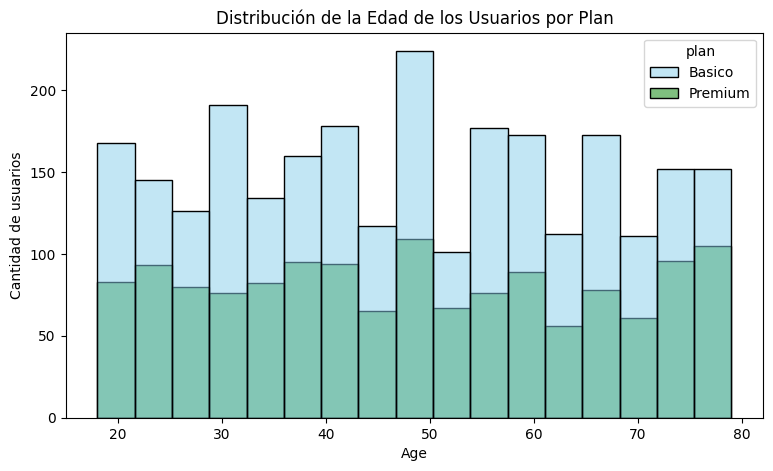

In [29]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))
sns.histplot(x = user_profile["age"], palette=['skyblue','green'], hue = user_profile["plan"])
plt.title("Distribución de la Edad de los Usuarios por Plan")
plt.xlabel("Age")
plt.ylabel("Cantidad de usuarios")
plt.show()

**Insights:**
La distribución de las edades es bastante uniforme y abarca un amplio rango desde los 20 hasta los 80 años sin mostrar un sesgo marcado. De igual modo, la proporción entre el plan Basico y el Premium se mantiene equilibrada y constante en prácticamente todos los grupos de edades, lo que demuestra que la edad no es un factor determinante ni diferenciador en la elección del tipo de plan de los usuarios.

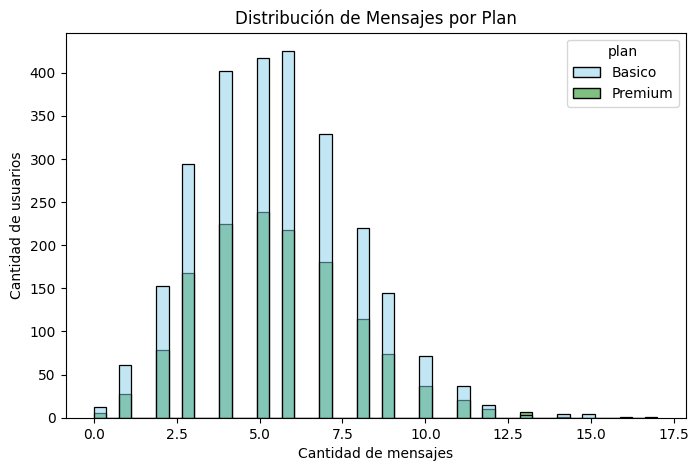

In [30]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(8, 5))
sns.histplot(x = user_profile["cant_mensajes"], palette=['skyblue','green'], hue = user_profile["plan"])
plt.title("Distribución de Mensajes por Plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

**Insights:**
La distribución de la cantidad de mensajes muestra un sesgo claro hacia la derecha, concentrando la mayor parte de los usuarios entre los 3 y 7 mensajes, con un pico máximo alrededor de los 5 y 6 mensajes. Además, la proporción entre ambos planes se mantiene bastante equilibrada en los valores más frecuentes, lo que indica que el volumen de mensajes enviando no presenta una diferenciación radical según el tipo de plan contratado.

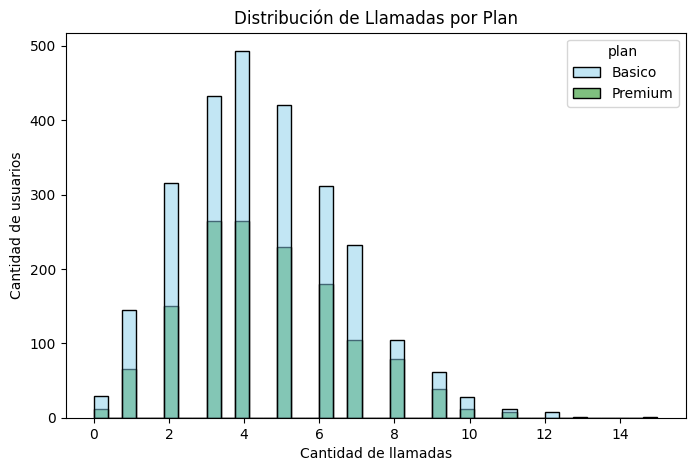

In [31]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(8, 5))
sns.histplot(x = user_profile["cant_llamadas"], palette=['skyblue','green'], hue = user_profile["plan"])
plt.title("Distribución de Llamadas por Plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

**Insights:** 
La distribución de la cantidad de llamadas presenta un claro sesgo hacia la derecha, concentrando a la mayoría de los usuarios en un rango de 3 a 6 llamadas, con un punto máximo que alcanza las 4 llamadas. Del mismo modo, se advierte que ambos planes mantienen una participación muy equilibrada en los niveles de frecuencia más altos, lo que evidencia que la cantidad de llamadas realizadas no representa un comportamiento diferenciador marcado entre los usuarios del plan Básico y el Premium.

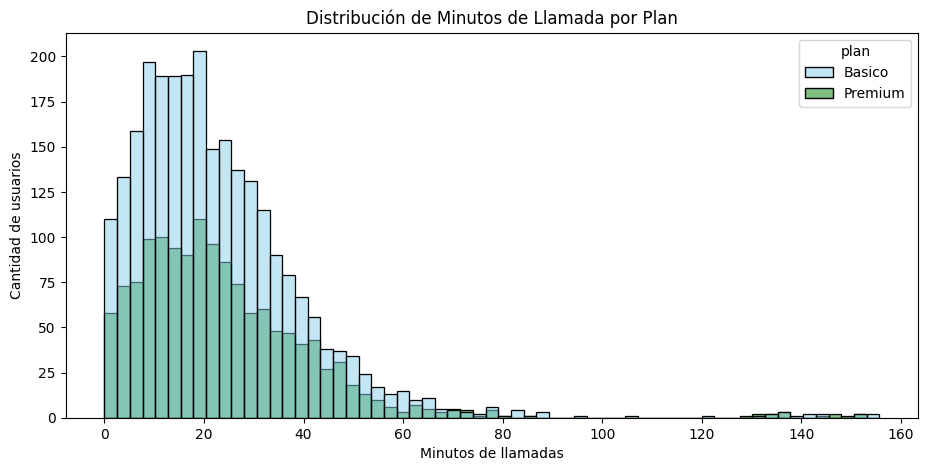

In [32]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(11, 5))
sns.histplot(x = user_profile["cant_minutos_llamada"], palette=['skyblue','green'], hue = user_profile["plan"])
plt.title("Distribución de Minutos de Llamada por Plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()


**Insights:** 
La distribución de los minutos de llamada muestra un marcado sesgo hacia la derecha, concentrando a la gran mayoría de los usuarios entre los 10 y 30 minutos, con un punto máximo que ronda los 20 minutos. Además, se observa una cola larga con valores extremos hacia la derecha superiores a los 120 minutos y se logra identificar, que ambos planes mantienen una participación proporcional y equilibrada a lo largo de toda la distribución, evidenciando que el tiempo total de llamadas no varía de manera radical según el tipo de plan.

## 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

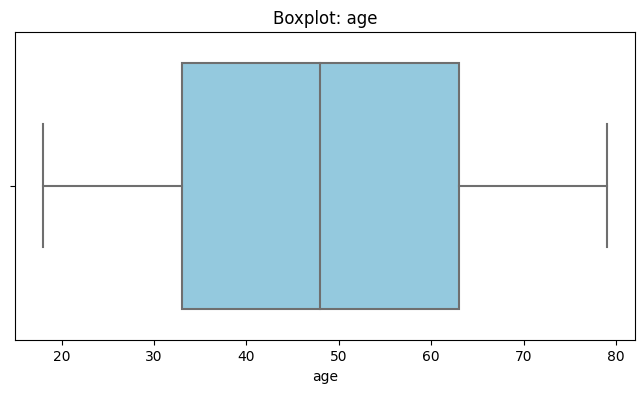

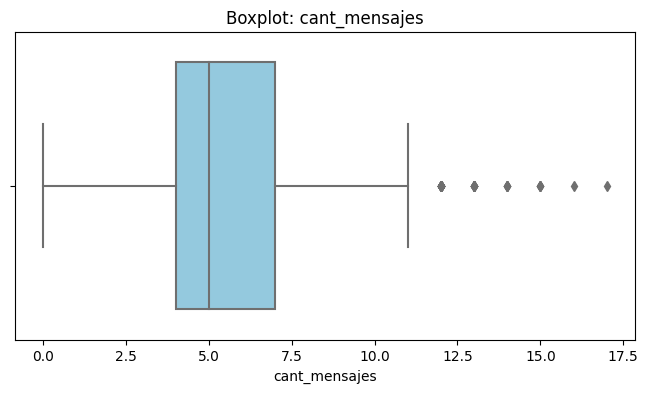

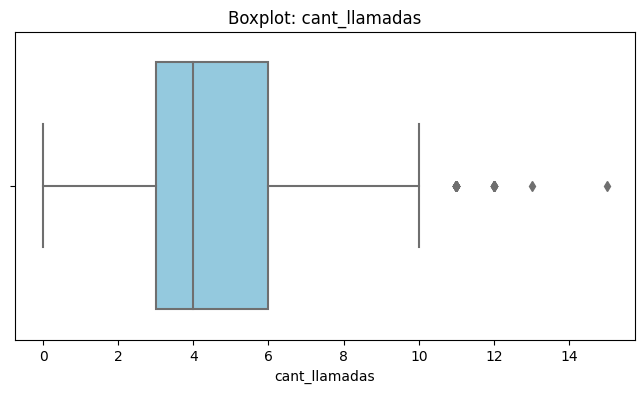

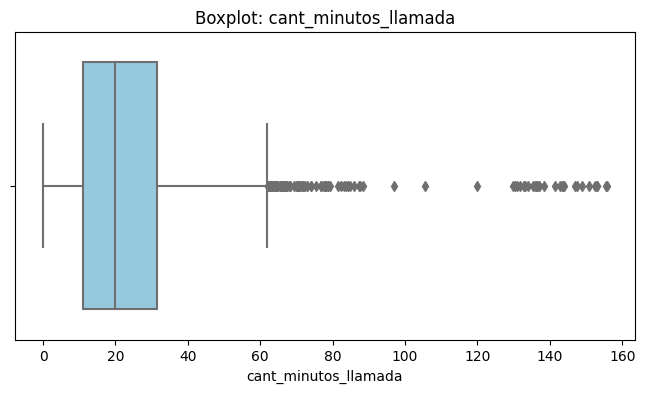

In [33]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data= user_profile, x=col, color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

**Insights:** 
Se identifican outliers  principalmente en las variables de uso cant_mensajes, cant_llamadas y cant_minutos_llamada, los cuales se visualizan como puntos aislados hacia la derecha de los boxplots. En el caso de age, la distribución se mantiene mucho más contenida dentro de los rangos intercuartílicos normales y no se evidencia ningun outlier.

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

limites = {}

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    limites[col] = (limite_inferior, limite_superior) 
    print(col, limites[col]) 

cant_mensajes (-0.5, 11.5)
cant_llamadas (-1.5, 10.5)
cant_minutos_llamada (-19.322500000000005, 61.8575)


In [35]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


**Insights:** 
- **Cantidad de mensajes:** El límite superior se sitúa en 11.5 frente a un valor máximo real de 17.0, la decisión es mantener los outliers. Aunque existen registros que superan el umbral, se trata de una desviación moderada de apenas 5.5 unidades por encima del límite; al observar que la media es de 5.5 y el percentil 75 se encuentra en 7, enviar hasta 17 mensajes diarios representa un comportamiento totalmente realista y propio de un usuario activo, por lo que no constituye un error de sistema.
- **Cantidad de llamadas:** Presenta un límite superior de 10.5 y un máximo real de 15.0, también se deben conservar los valores extremos. Esta diferencia representa un exceso moderado de solo 4.5 llamadas por encima del límite, de modo que los clientes ubicados en ese rango reflejan una alta frecuencia comunicativa que se alinea de forma coherente con patrones de uso humanos y legítimos dentro de la red.
- **Minutos totales de llamada:** los cuales registran un límite superior de 61.86 y un valor máximo elevado de 155.69, la recomendación de mantener los outliers se mantiene, aunque  aquí el desvío es mucho más extremo, llegando a casi el triple del límite establecido. A pesar de lo apartado de estos valores, estos puntos identifican con precisión a los  clientes de alto valor como personas que utilizan el servicio de forma intensiva para trabajo o llamadas extensas, por lo que eliminarlos implicaría un sesgo importante al suprimir información esencial sobre la actividad real del negocio.

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos


In [36]:
# Crear columna grupo_uso
def clasificacion_clientes(row):
    mensajes = row['cant_mensajes']
    llamadas = row['cant_llamadas']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'


user_profile["grupo_uso"] = user_profile.apply(clasificacion_clientes, axis=1) 
user_profile["grupo_uso"].value_counts()
    

Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64

In [37]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [38]:
# Crear columna grupo_edad
def clasificacion_clientes_edad(row):
    age = row['age']
    
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile["grupo_edad"] = user_profile.apply(clasificacion_clientes_edad, axis=1) 
user_profile["grupo_edad"].value_counts()

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [39]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.


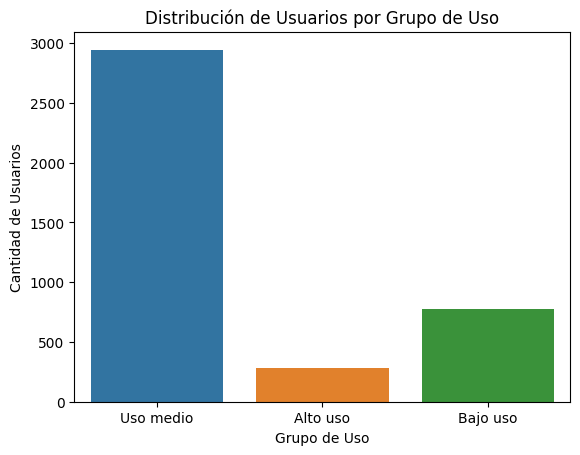

In [41]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

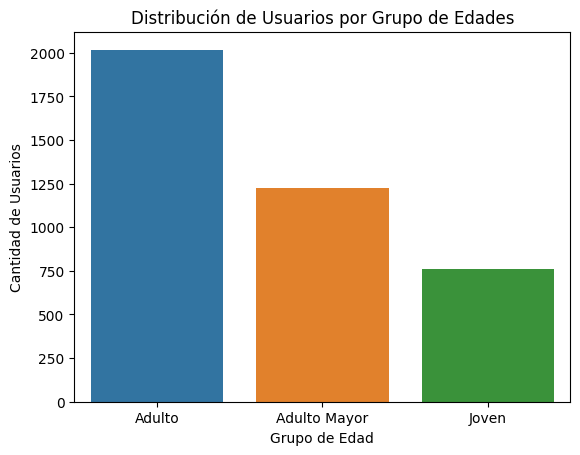

In [42]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por Grupo de Edades')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Originalmente las variables numéricas de actividad (cant_mensajes, cant_llamadas y cant_minutos_llamada) presentaban valores extremos elevados que requerían un análisis profundo mediante el rango intercuartílico (IQR).
- Aunque estos valores se apartaban de los límites superiores calculados (11.5 para mensajes, 10.5 para llamadas y 61.86 para minutos), se determinó tras la inspección estadística que no representaban errores de sistema ni datos corruptos, por lo que se decidió conservarlos en su totalidad para no perder información crítica del negocio.


🔍 **Segmentos por Edad**
- La segmentación permitió agrupar a la base de clientes en tres categorías clave: Jóvenes (menores de 30 años) con un estimado de 750 usuarios, Adultos (entre 30 y 59 años)con un aproximado de 2000 usuarios y Adultos Mayores (60 años en adelante) con casi 1250 usuarios.
- Esta distribución por edades permite observar cómo se comportan los diferentes rangos generacionales frente a los canales de comunicación tradicionales de la compañía, destacando que el segmento de los jóvenes presentó la menor cantidad de usuarios en comparación con los demás grupos y el grupo de los adultos una mayor cantidad de usuarios.


📊 **Segmentos por Nivel de Uso**
- Se clasificó a los usuarios según su frecuencia combinada de llamadas y mensajes en tres categorías clave: Bajo uso (menos de 5 llamadas y mensajes), que agrupa a menos de 1000 usuarios; Uso medio (menos de 10), que concentra la mayor parte de la base con casi 3000 usuarios; y Alto uso (el resto de los casos), con alrededor de 1250 usuarios.
- El análisis de estos grupos revela una distribución equilibrada donde el bloque de "Uso medio" lidera la participación, lo que demuestra que la gran mayoría de la base mantiene una interacción constante y moderada con los servicios de la compañía, respaldada por un segmento robusto de alto rendimiento.


➡️ **Esto sugiere que**
- Los clientes con mayor volumen de interacción coexisten con outliers extremos en los minutos de llamada (que triplican el límite superior de 61.86 alcanzando hasta 155.69 minutos), conformando el núcleo de los clientes de alto valor que sostienen el mayor tráfico de la red.
- Por el contrario, el segmento Joven (con solo 750 usuarios) y el grupo de Bajo uso (menos de 1000 usuarios) representan áreas de oportunidad donde la penetración actual es menor y se requiere una estrategia de atracción y reactivación.
- Existe una alta concentración de valor en el segmento de Adultos (con 2000 usuarios) y en el grupo de Uso medio/Alto uso (que suman más de 4000 usuarios activos), lo que indica que la masa crítica de la empresa se encuentra en clientes maduros con una interacción frecuente y constante.

💡 **Recomendaciones**
- Estrategias de fidelización para la mayoría de grupo de edades consolidada, implementando programas de beneficios y mejoras en la oferta actual dirigidos al bloque de Adultos y usuarios de Uso medio, asegurando la estabilidad de la base principal de ingresos.
- Diseñar planes personalizados para los clientes de alto valor o clientes "whale" y consumo intensivo aprovechando la identificación de los valores extremos en minutos de llamada para crear paquetes ilimitados o tarifas preferenciales orientadas a retener y monetizar formalmente a este segmento clave.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`